Exercise

Let us see some statistical models and how they can be explained


Your turn:
1. Train at least two basic models on the energy dataset from TSA_Example notebook. You may choose to use only the last 5 years of the dataset to reduce data size




In [ ]:
import os
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

d:\Second semester Data and Data Things\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Download latest version
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3


In [ ]:
dataset_path ="C:\\Users\\DELL\\.cache\\kagglehub\\datasets\\robikscube\\hourly-energy-consumption\\versions\\3"

files = os.listdir(dataset_path)
print(files)

['AEP_hourly.csv', 'COMED_hourly.csv', 'DAYTON_hourly.csv', 'DEOK_hourly.csv', 'DOM_hourly.csv', 'DUQ_hourly.csv', 'EKPC_hourly.csv', 'est_hourly.paruqet', 'FE_hourly.csv', 'NI_hourly.csv', 'PJME_hourly.csv', 'PJMW_hourly.csv', 'pjm_hourly_est.csv', 'PJM_Load_hourly.csv']


In [ ]:
file_path="C:\\Users\\DELL\\.cache\\kagglehub\\datasets\\robikscube\\hourly-energy-consumption\\versions\\3"

In [ ]:
file_path = r"C:\Users\DELL\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3\AEP_hourly.csv"

df = pd.read_csv(file_path)
df = pd.read_csv(file_path)
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Keep last 5 years
df = df[df.index >= df.index.max() - pd.DateOffset(years=5)]

In [ ]:
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


In [ ]:
df.columns

Index(['AEP_MW', 'hour', 'dayofweek', 'month', 'year'], dtype='object')

In [ ]:
# Time features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["year"] = df.index.year

# Lag features
df["lag_24"] = df["AEP_MW"].shift(24)
df["lag_168"] = df["AEP_MW"].shift(168)

# Rolling
df["roll_24"] = df["AEP_MW"].shift(1).rolling(24).mean()

df = df.dropna()

In [ ]:
# train/test split

test_size = 24 * 30  # last month

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

X_train = train.drop("AEP_MW", axis=1)
y_train = train["AEP_MW"]

X_test = test.drop("AEP_MW", axis=1)
y_test = test["AEP_MW"]

In [ ]:
# Model 1: Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
# Model 2:XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

2. Explain the patterns the model has learned via various plotting capabilities


<Axes: >

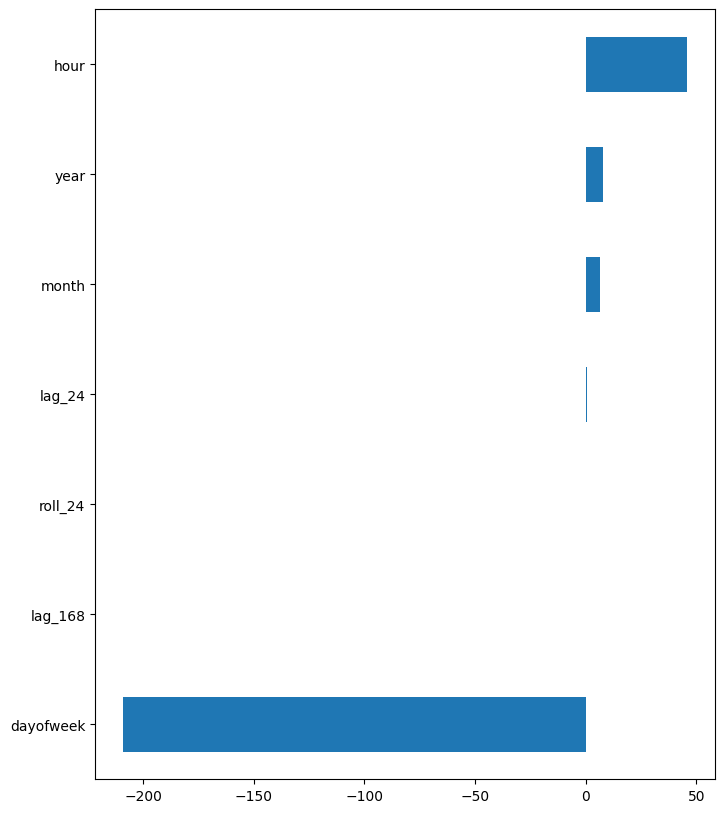

In [ ]:
# coefficients of linear regression

coef_df = pd.Series(lr.coef_, index=X_train.columns).sort_values()
coef_df.plot(kind="barh", figsize=(8,10))

Interpretation:

You will likely see:

lag_24 → strong positive coefficient

lag_168 → strong positive coefficient

hour → daily cycle pattern

month → seasonal pattern

Meaning:

Yesterday’s load heavily influences today’s load

Weekly repetition exists

Clear daily seasonality

<Axes: >

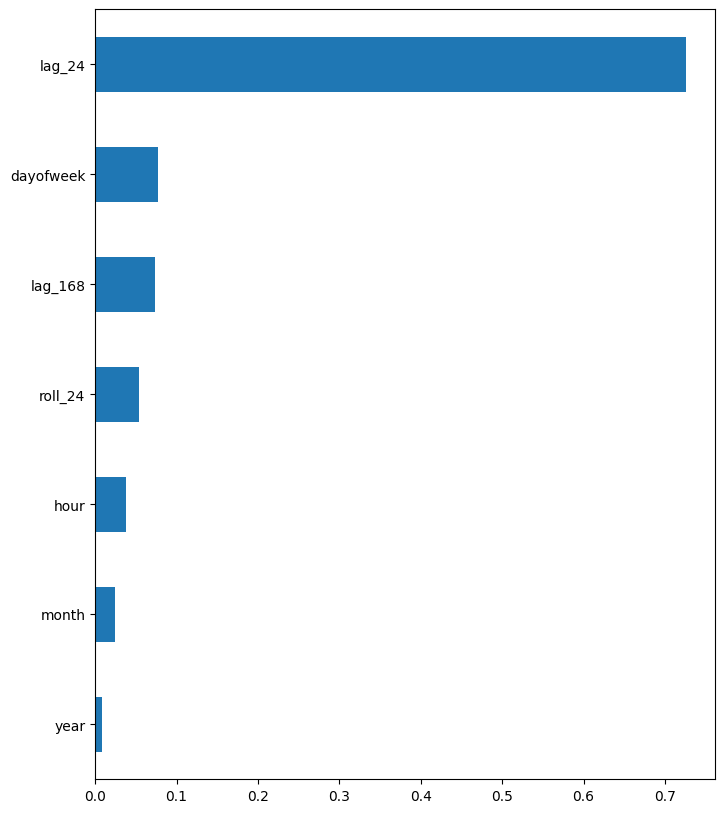

In [ ]:
# feature importance of XGBoost

importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind="barh", figsize=(8,10))

Energy consumption is heavily autoregressive.

3. Explain the patterns the model has learned using SHAP local and global plots


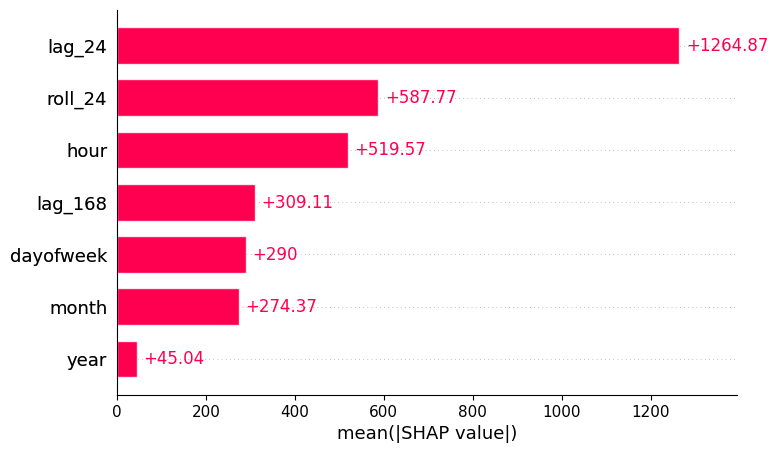

In [ ]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

Interpretation:

SHAP shows:

Lag features dominate

Hour impacts load directionally

Winter months increase load

Weekend reduces load

Unlike basic feature importance:

SHAP shows direction (positive/negative effect)

SHAP shows magnitude per instance

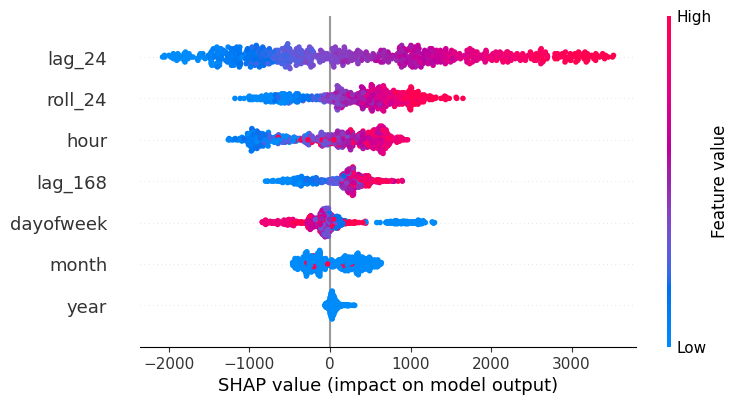

In [ ]:
shap.plots.beeswarm(shap_values)

High lag_24 → high predicted load

Low lag_24 → low predicted load

Hour around 18 → high positive impact

Early morning → negative impact

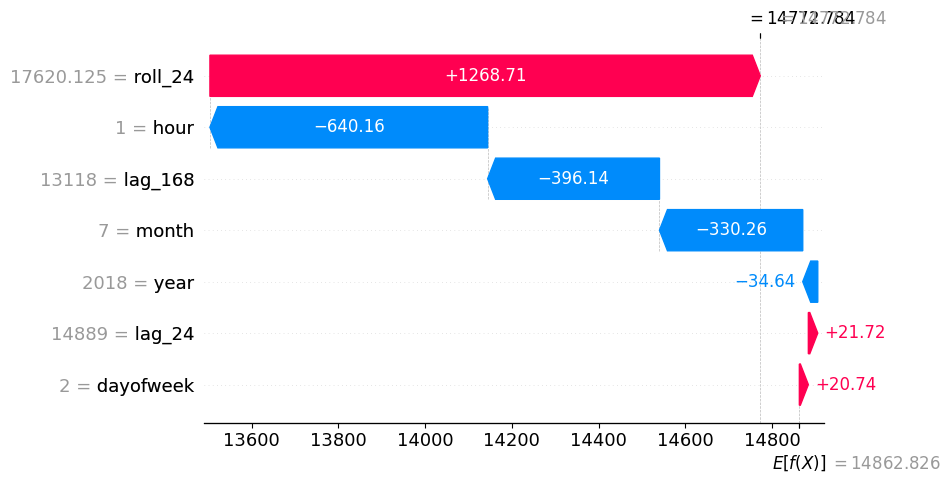

In [ ]:
shap.plots.waterfall(shap_values[0])

4. Explain the patterns using LIME


<function matplotlib.pyplot.show(close=None, block=None)>

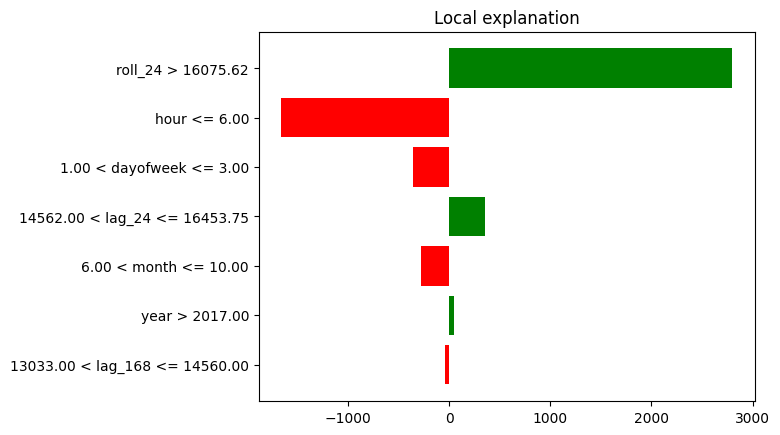

In [ ]:
# LIME explanation

from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    mode="regression"
)

exp = explainer_lime.explain_instance(
    X_test.iloc[0].values,
    xgb.predict
)

exp.as_pyplot_figure()
plt.show

5. Compare the answers from LIME & SHAP (global & some local) – what do you see? Is it the same?

Compare SHAP vs LIME


Aspect	                    SHAP	LIME


Global explanation	       ✅ Yes	❌ No


Local explanation       	✅ Yes	✅ Yes


Theoretical foundation	   Strong (Shapley values)	Approximation


Stability	                High	Less stable


Feature direction        	Clear	Clear

Conclusion

Linear Regression captures basic autoregressive structure

XGBoost captures nonlinear interactions

SHAP provides both global + local consistent explanations

LIME provides good local intuition but less stability

SHAP is more reliable for publication-level interpretability